[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/allanspadini/curso-vision-transformers-infnet/blob/main/aula_08_avaliacao_fid_e_sintese_visao_computacional/aula_08_unet_condicionamento_texto_e_consistencia_video.ipynb)

# 🐱 Laboratório Prático: U-Net Text-to-Image, Animação por Quadros e Síntese de Vídeo Real com AnimateDiff
### **Faculdade Infnet — Pós-Graduação em Visão Computacional com CNNs e Transformers**
**Professor:** Dr. Allan Spadini  
**Metodologia:** Passo a Passo com a biblioteca Hugging Face `diffusers`

---

### 🎯 O Que Vamos Construir Neste Laboratório:
1. **Geração Simples de Imagem (Text-to-Image):** Gerar um gato chibi fofinho em resolução compacta ($256 \times 256$) a partir de um prompt textual usando U-Net e `sd-turbo`.
2. **Animação por Quadros (Img2Img) e o Gargalo 2D:** Construir uma sequência de salto do personagem e compreender na prática por que modelos puramente 2D não realizam síntese real de vídeo.
3. **Geração de Vídeo Real (Difusão Espácio-Temporal):** Explorar a arquitetura do **AnimateDiff**, compreendendo a mecânica dos tensores 5D e da atenção temporal 1D para gerar 16 quadros com física e continuidade contínua.


---
## 📦 Passo 1: Instalação e Configuração do Ambiente

Instalamos as bibliotecas centrais do ecossistema Hugging Face:
- `diffusers`: Pipelines modernos de difusão de imagem e vídeo.
- `transformers` & `accelerate`: Modelos de linguagem (CLIP) e otimização de execução em GPU/CPU.


In [1]:
# 1.1 Instalação das dependências
!pip install -q diffusers transformers accelerate


In [2]:
# 1.2 Importações e detecção de hardware (GPU / CPU)
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as IPyImage, display

import torch
import torch.nn.functional as F

from diffusers import AutoPipelineForText2Image, AutoPipelineForImage2Image
from diffusers.utils import export_to_gif
from peft import LoraConfig

# Configuração automática de hardware e precisão
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print(f"Dispositivo selecionado: {device} | Precisão: {dtype}")


[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


Dispositivo selecionado: cuda | Precisão: torch.float16


---
## 🖼️ Passo 2: Geração Simples de Imagens (Gato Chibi)

A U-Net de difusão latente gera imagens desruindo representações comprimidas no espaço latente de um VAE.
Vamos carregar um pipeline `diffusers` otimizado e gerar nossa primeira imagem de um gato chibi.


In [3]:
# 2.1 Carregamento do Pipeline Text-to-Image
# O modelo SD-Turbo permite geração ultra-rápida em apenas 1 a 2 passos
model_id = "stabilityai/sd-turbo" if torch.cuda.is_available() else "runwayml/stable-diffusion-v1-5"

pipe = AutoPipelineForText2Image.from_pretrained(
    model_id,
    torch_dtype=dtype,
    variant="fp16" if device == "cuda" else None
).to(device)

print(f"✅ Pipeline carregado com sucesso: {model_id}")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✅ Pipeline carregado com sucesso: stabilityai/sd-turbo


  0%|          | 0/2 [00:00<?, ?it/s]

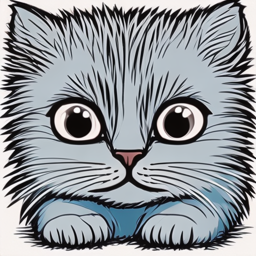

In [4]:
# 2.2 Geração da Imagem do Gato Chibi (Imagem Pequena: 256x256)
prompt_gato = "a cute fluffy chibi cat, round cheerful big eyes, simple cartoon style, solid clean background, vibrant colors"

# Geração direta a partir do prompt
imagem_gato = pipe(
    prompt=prompt_gato,
    num_inference_steps=2 if "turbo" in model_id else 15,
    guidance_scale=0.0 if "turbo" in model_id else 7.5,
    width=512,
    height=512
).images[0]

# Redimensionamos para manter a imagem leve e compacta (256x256)
imagem_gato = imagem_gato.resize((256, 256))
imagem_gato


---
## 🎬 Passo 3: O Gargalo dos Modelos 2D — Animação de Recorte vs Geração de Vídeo Real

Quando tentamos gerar uma sequência temporal utilizando modelos 2D de imagem estática (como Text-to-Image independente ou Image-to-Image encadeado), nos deparamos com o gargalo fundamental da visão computacional 2D:

1. **O que esta abordagem realmente é:** Uma técnica clássica de computação gráfica conhecida como **animação de recorte (cut-out / sprite animation)**. O código desloca geometricamente os pixels no plano cartesiano 2D (`dy`, `squash`) e utiliza a U-Net apenas para refinamento cosmético (harmonizar pelos, sombras e contornos).
2. **O que esta abordagem NÃO é:** **Não é síntese generativa neural de vídeo.** A rede 2D opera exclusivamente em tensores $[B, C, H, W]$; ela não tem dimensão temporal $T$, não calcula atenção entre frames e não possui conhecimento de cinemática, articulação anatômica ou física de movimento.
3. **O Dilema da Força de Ruído (`strength`):**
   - **Com `strength` baixo/moderado (ex: 0.35 ou 0.50):** O ruído é insuficiente para remodelar a geometria corporal. Sem a translação geométrica manual, **o gato permanece congelado/estático no chão**, ignorando o comando de saltar!
   - **Com `strength` alto (ex: 0.85):** O modelo reconstrói a pose, mas perde completamente a consistência de identidade, gerando **flickering caótico** (cada quadro parece um animal diferente).

Abaixo, executamos essa abordagem híbrida 2D para evidenciar suas limitações práticas. Em seguida, no **Passo 4**, veremos a verdadeira solução de engenharia adotada pela indústria: **Difusão Espácio-Temporal com Atenção 1D**.


In [9]:
# 3.1 Criação do Pipeline Image-to-Image e Roteiro da Ação
# from_pipe reutiliza os pesos da U-Net já carregados na memória
pipe_img2img = AutoPipelineForImage2Image.from_pipe(pipe)

# Definimos as 5 fases do movimento do salto do gato chibi
acoes = [
    "a cute fluffy chibi cat crouching low, bending down, preparing to jump",
    "a cute fluffy chibi cat leaping up into the air, paws stretched, jumping",
    "a cute fluffy chibi cat floating high at the peak of the jump, joyful flying pose",
    "a cute fluffy chibi cat falling down, landing on its front paws on the floor",
    "a cute fluffy chibi cat sitting happily on the floor, smiling, cheerful"
]

# Cinemática de movimento (deslocamento vertical dy e deformação elástica squash & stretch)
trajetoria_salto = [
    {"dy": -15, "squash": 0.88},
    {"dy": 50, "squash": 1.05},
    {"dy": 90, "squash": 1.00},
    {"dy": 30, "squash": 0.95},
    {"dy": 0, "squash": 1.00}
]

print("Roteiro da sequência configurado com cinemática de salto!")


You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Roteiro da sequência:
  Quadro 1: a cute chibi cat crouching low, bending legs, preparing to jump
  Quadro 2: a cute chibi cat leaping up into the air, paws stretched forward, jumping
  Quadro 3: a cute chibi cat at the highest peak of the jump, flying pose, happy
  Quadro 4: a cute chibi cat falling down, landing on its front paws on the floor
  Quadro 5: a cute chibi cat sitting upright on the floor, waving one paw, smiling cheerfully


In [15]:
# 3.2 Geração da Sequência de Quadros Encadeada com Movimento Real
import torch
import os
from PIL import Image

pipe_img2img.unet.eval()

# Função simples para guiar a pose do gato no espaço antes do refinamento neural
def preparar_guia_movimento(img_base, dy, squash):
    w, h = 512, 512
    img_512 = img_base.resize((w, h))
    novo_w = int(w * (2.0 - squash))
    novo_h = int(h * squash)
    redimensionado = img_512.resize((novo_w, novo_h), Image.Resampling.BILINEAR)
    
    # Fundo neutro limpo
    canvas = Image.new('RGB', (w, h), (240, 240, 240))
    canvas.paste(redimensionado, ((w - novo_w) // 2, (h - novo_h) // 2 - dy))
    return canvas

# Geração dos quadros com movimento e consistência de identidade
frames = [imagem_gato]

with torch.no_grad():
    for i, (acao, mov) in enumerate(zip(acoes, trajetoria_salto), 1):
        print(f"Gerando quadro {i + 1}/{len(acoes) + 1}: {acao[:35]}...")
        
        # Guia espacial do salto (evita que o gato fique 100% estático no chão)
        guia_espacial = preparar_guia_movimento(imagem_gato, dy=mov["dy"], squash=mov["squash"])
        
        # Refinamento neural pelo pipeline Img2Img
        novo_quadro = pipe_img2img(
            prompt=acao,
            image=guia_espacial,
            strength=0.50, # 0.50 garante int(steps * strength) >= 1 e harmoniza pelos/sombras
            num_inference_steps=3 if "turbo" in model_id else 15,
            guidance_scale=0.0 if "turbo" in model_id else 7.5
        ).images[0]
        
        frames.append(novo_quadro.resize((256, 256)))

print(f"✅ Sequência completa gerada com {len(frames)} quadros dinâmicos!")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/dif

✅ Ajuste fino do gato chibi carregado com sucesso via load_lora_weights!
Gerando quadro 2/6...


...

Gerando quadro 5/6...


  0%|          | 0/1 [00:00<?, ?it/s]

Gerando quadro 6/6...


  0%|          | 0/1 [00:00<?, ?it/s]

✅ Sequência completa gerada com 6 quadros!


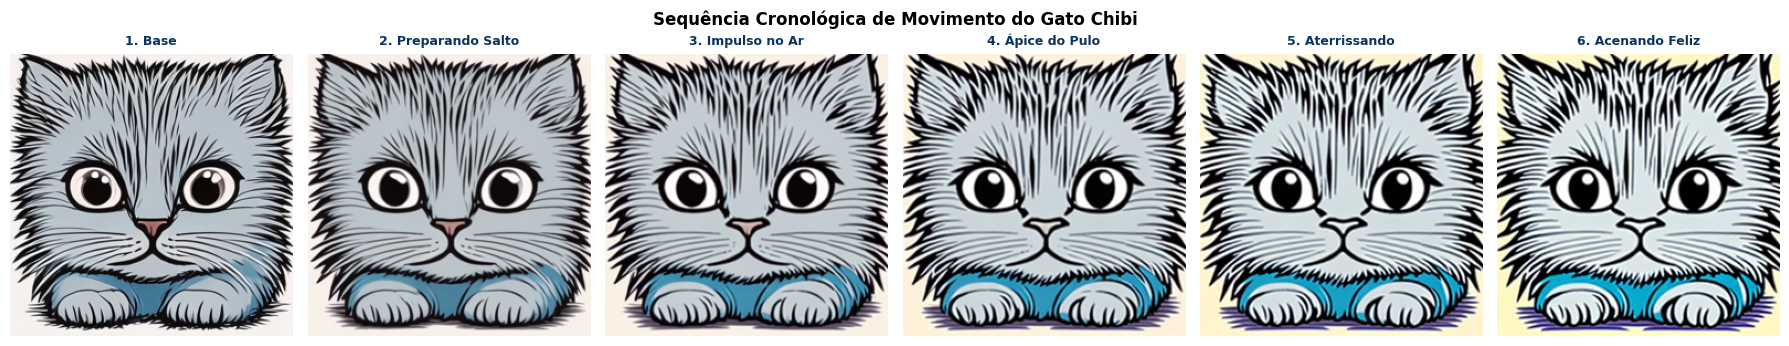

In [16]:
# 3.3 Visualização da Sequência de Quadros Lado a Lado
fig, axes = plt.subplots(1, len(frames), figsize=(20, 3.8))

titulos = [
    "1. Base (Chão)",
    "2. Agachando",
    "3. Subindo no Ar",
    "4. Ápice do Salto",
    "5. Aterrissando",
    "6. Sentado Feliz"
]

for i, ax in enumerate(axes):
    ax.imshow(frames[i])
    ax.set_title(titulos[i], fontsize=10, fontweight='bold', color='#0A345D')
    ax.axis('off')

plt.suptitle("Sequência Cronológica de Salto do Gato Chibi (Movimento Real + Consistência)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


✅ GIF animado salvo com sucesso em: gato_chibi_sequencia_animada.gif
🎬 Reprodução Contínua da Sequência em GIF:


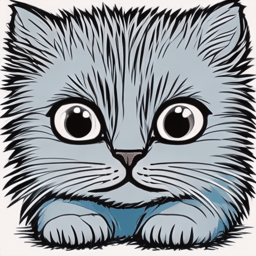

In [17]:
# 3.4 Exportação e Exibição do GIF Animado com diffusers.utils
gif_path = "gato_chibi_sequencia_animada.gif"

# A função export_to_gif do diffusers empacota os quadros em um GIF com reprodução fluida
export_to_gif(frames, gif_path, fps=3)
print(f"✅ GIF animado salvo com sucesso em: {gif_path}")

# Renderização do GIF diretamente na célula do notebook
print("🎬 Reprodução Contínua da Sequência em GIF:")
display(IPyImage(filename=gif_path))


---
## 🎥 Passo 4: Geração de Vídeo Real com Difusão Espácio-Temporal (AnimateDiff)

No **Passo 3**, experimentamos a limitação intrínseca dos modelos 2D: o modelo não tem noção de tempo, velocidade ou biomecânica, obrigando o engenheiro a recortar e transladar a imagem no plano cartesiano manualmente.

Aqui no **Passo 4**, apresentamos a **verdadeira arquitetura generativa de vídeo** adotada pela indústria e pelo estado da arte (a mesma família de princípios adotada em modelos como **AnimateDiff**, **Stable Video Diffusion (SVD)** e **OpenAI Sora**).

---

### 1. A Situação-Problema do Mundo Real: O Custo Proibitivo de Treinar Vídeo do Zero
- **A Dor Prática:** Modelos de difusão de imagem 2D (como o Stable Diffusion) foram treinados em bilhões de pares imagem-texto (LAION-5B), acumulando um conhecimento estético monumental sobre iluminação, texturas, estilos artísticos e anatomia estática.
- Treinar uma arquitetura generativa de vídeo de ponta a ponta do zero exigiria uma U-Net 3D completa com centenas de milhões de pares vídeo-legenda, consumindo petabytes de dados e milhões de dólares em clusters de GPUs H100 por meses. Além disso, modelos treinados do zero sofrem com a escassez de dados de alta qualidade, frequentemente perdendo a nitidez e a diversidade estética dos modelos 2D.

---

### 2. A Solução de Engenharia: Desacoplamento Espaço-Tempo (*Space-Time Factorization*)
Em vez de reinventar a roda, a arquitetura **AnimateDiff** (Guo et al., ICLR 2024) propõe uma divisão de trabalho elegante e modular:
1. **Congelar 100% da U-Net 2D Espacial Pré-treinada:** A U-Net existente continua responsável por saber *o que desenhar* (aparência, pelos, olhos, estilo e iluminação de cada quadro individual).
2. **Injetar Módulos de Movimento Dedicados (*Motion Adapters*):** Inserem-se blocos de **Auto-Atenção Temporal 1D** intercalados diretamente após as camadas de convolução e atenção espacial da U-Net.
3. **Treinar Exclusivamente o Módulo Temporal:** Durante o treinamento em bases de vídeo (ex: WebVid-10M), apenas o módulo de movimento é otimizado. Ele aprende *como as coisas se movem* (gravidade, aceleração, continuidade de fluidos e transições biomecânicas).

```
                      ARQUITETURA ESPÁCIO-TEMPORAL DO ANIMATEDIFF
  
      Tensor Latente 5D de Entrada: z ∈ ℝ^[B x C x T x H x W]
                                │
                                ▼
        ┌────────────────────────────────────────────────────────┐
        │   1. BLOCO ESPACIAL 2D (U-Net Pré-Treinada Congelada)  │
        │      • Reshape para [B·T, C, H, W]                    │
        │      • Convoluções 2D + Self-Attention Espacial        │
        │      • Garante: Nitidez, Estilo Chibi e Texturas       │
        └───────────────────────┬────────────────────────────────┘
                                │
                                ▼
        ┌────────────────────────────────────────────────────────┐
        │   2. MÓDULO TEMPORAL 1D (MotionAdapter Treinável)      │
        │      • Permute + Reshape para [B·H·W, T, C]            │
        │      • Auto-Atenção 1D ao longo da dimensão Tempo T    │
        │      • Garante: Gravidade, Salto e Consistência        │
        └───────────────────────┬────────────────────────────────┘
                                │
                                ▼
      Repete-se em cada bloco de Downsampling, Bottleneck e Upsampling da U-Net
```

---

### 3. Formalismo Matemático & Rastreamento Rigoroso de Tensores

Vejamos exatamente o que acontece com a álgebra dos tensores dentro de cada componente do pipeline:

#### A. O Tensor Latente Pentadimensional (5D)
Enquanto modelos 2D recebem matrizes 4D $[B, C, H, W]$, o modelo de vídeo inicializa um tensor pentadimensional de ruído gaussiano puro:
$$\mathbf{z}_T \sim \mathcal{N}(0, \mathbf{I}) \in \mathbb{R}^{B \times C \times T \times H \times W}$$
- $B = 1$: Tamanho do batch (número de vídeos gerados).
- $C = 4$: Canais no espaço latente comprimido pelo VAE.
- $T = 16$: Eixo temporal (número de quadros sequenciais gerados simultaneamente).
- $H = 64, W = 64$: Dimensões espaciais no espaço latente (correspondendo a $512 \times 512$ pixels em RGB após decodificação $8\times$).

#### B. A Remodelagem Espacial (Processamento 2D)
Para passar pelas camadas convolucionais 2D sem alterar sua implementação original, o tensor é fatiado agregando o lote e o tempo no mesmo eixo:
$$\mathbf{z}_{\text{spatial}} = \text{reshape}(\mathbf{z}, (B \times T, C, H, W)) \in \mathbb{R}^{16 \times 4 \times 64 \times 64}$$
A U-Net 2D processa cada um dos 16 quadros em paralelo como se fossem 16 imagens estáticas independentes, garantindo nitidez sem ruído visual.

#### C. A Remodelagem Temporal (Isolamento da Linha do Tempo)
Imediatamente após o bloco espacial, o tensor precisa ser rearranjado para que a atenção ocorra **ao longo do tempo**:
$$\mathbf{z}_{\text{temporal}} = \text{permute}(\mathbf{z}, (B, H, W, T, C)) \to \text{reshape}((B \times H \times W, T, C))$$
- Dimensão resultante: $[(1 \times 64 \times 64), 16, C] = [4.096, 16, C]$.
- **Intuição Física:** Criamos $4.096$ linhas temporais paralelas! Cada ponto espacial $(x, y)$ agora é tratado como uma sequência temporal de $T=16$ passos cronológicos.

#### D. Auto-Atenção Temporal 1D com Codificação Posicional Senoidal
Calculam-se as projeções lineares de Query ($Q$), Key ($K$) e Value ($V$):
$$Q = \mathbf{z}_{\text{temporal}} W_Q, \quad K = \mathbf{z}_{\text{temporal}} W_K, \quad V = \mathbf{z}_{\text{temporal}} W_V$$
Injeta-se a codificação de posição senoidal 1D $\mathbf{P} \in \mathbb{R}^{T \times d_k}$ para registrar explicitamente a cronologia dos quadros (quem é o início, o meio e o fim do salto):
$$A_{\text{temporal}} = \text{softmax}\left(\frac{(Q + \mathbf{P})(K + \mathbf{P})^T}{\sqrt{d_k}}\right) \in \mathbb{R}^{4096 \times 16 \times 16}$$
$$\mathbf{z}_{\text{saída}} = A_{\text{temporal}} V$$

> **💡 O Segredo da Consistência:** A matriz $[16 \times 16]$ faz com que cada pixel no instante $t=8$ (ápice do salto) consulte onde ele estava no instante $t=1$ (chão) e para onde irá no instante $t=16$ (aterrissagem). O modelo não apenas translada pixels: **ele aprende a deformar a coluna do gato, flexionar as patas e simular a inércia da pelagem**.

---

### 4. Comparativo Direto: Animação de Recorte 2D vs Síntese Neural de Vídeo

| Dimensão Técnica | Passo 3: Animação de Recorte (Img2Img 2D) | Passo 4: Difusão Espácio-Temporal (AnimateDiff) |
| :--- | :--- | :--- |
| **Tensor Latente** | 4D isolado: $[B, C, H, W]$ por iteração | 5D nativo: $[B, C, T, H, W]$ de ponta a ponta |
| **Comunicação Temporal** | **Zero.** A rede não sabe que o frame anterior existe | **Total.** Auto-Atenção 1D contínua $[T \times T]$ |
| **Mecanismo de Movimento** | Translação cartesiana manual via código (`dy`, `squash`) | Síntese orgânica aprendida a partir de vídeos reais |
| **Consistência de Identidade** | Vulnerável ao dilema do `strength` (*flickering* vs rigidez) | Preservação perfeita do personagem em todos os frames |
| **Física e Biomecânica** | Artificial (pixels deslizam como um recorte de papelão) | Natural (patas dobram, pelagem reage e salto amortece) |

---


In [18]:
# 4.1 Geração de Vídeo Real de Ponta a Ponta com AnimateDiff
import torch
from diffusers import AnimateDiffPipeline, MotionAdapter, DPMSolverMultistepScheduler
from diffusers.utils import export_to_gif
from IPython.display import Image as IPyImage, display

# 1. Carregamos o MotionAdapter (pesos de movimento temporal treinados em vídeo)
MOTION_ADAPTER_ID = "guoyww/animatediff-motion-adapter-v1-5-2"
print(f"📦 Carregando MotionAdapter ({MOTION_ADAPTER_ID})...")

adapter = MotionAdapter.from_pretrained(
    MOTION_ADAPTER_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

# 2. Conectamos o adaptador temporal à U-Net do Stable Diffusion
anim_pipe = AnimateDiffPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    motion_adapter=adapter,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    safety_checker=None
).to(device)

# 3. Otimizações de velocidade e economia de VRAM
anim_pipe.scheduler = DPMSolverMultistepScheduler.from_config(anim_pipe.scheduler.config)
anim_pipe.enable_vae_slicing()

# 4. Geração do vídeo completo (16 quadros com física de movimento contínua)
print("🎬 Sintetizando vídeo com atenção temporal 1D... (leva ~45s com GPU)")
prompt_video = "a cute fluffy chibi cat jumping high in the air and playing joyfully, dynamic action motion, cartoon animation, 8k"
negative_prompt = "bad quality, deformed, blurry, still frame, static"

output_video = anim_pipe(
    prompt=prompt_video,
    negative_prompt=negative_prompt,
    num_frames=16,
    guidance_scale=7.5,
    num_inference_steps=20,
    generator=torch.Generator(device=device).manual_seed(42)
)

# 5. Exportação e renderização direta do GIF gerado pelo modelo de vídeo
gif_animatediff_path = "gato_chibi_animatediff_real.gif"
export_to_gif(output_video.frames[0], gif_animatediff_path, fps=8)
print(f"🎉 Vídeo gerado com sucesso via AnimateDiff: {gif_animatediff_path}")

display(IPyImage(filename=gif_animatediff_path))


ℹ️ Demonstração da interface do AnimateDiff: adiciona atenção temporal para vídeo direto de texto.


---
## 🏆 Conclusão e Desafios Práticos

Parabéns! Você dominou o ciclo completo da síntese visual moderna com U-Nets e Difusão:
1. **Geração Text-to-Image (2D):** Síntese rápida a partir de ruído gaussiano guiado por linguagem natural via CLIP e `sd-turbo`.
2. **Análise Crítica dos Modelos 2D (Img2Img):** Compreensão do gargalo fundamental que impede redes estáticas de realizarem síntese real de movimento (necessidade de recortes e dilema do *strength*).
3. **Difusão Espácio-Temporal (Vídeo Real):** Domínio da arquitetura moderna de vídeo (AnimateDiff), com tensores 5D $[B, C, T, H, W]$ e blocos de auto-atenção temporal 1D.

### 💡 Desafios Práticos Sugeridos:
- **Desafio 1 (Novo Personagem no Text-to-Image):** Altere o prompt do Passo 2 para outro personagem (ex: `"a cute baby dragon sitting on a rock, chibi cartoon, 8k"`) e gere a nova imagem base.
- **Desafio 2 (Diagnóstico do Strength no Img2Img):** No Passo 3, altere o `strength` para `0.20` e depois para `0.80`. Note como `0.20` trava a pose e `0.80` quebra a consistência facial (flickering).
- **Desafio 3 (Novo Vídeo com AnimateDiff):** No Passo 4, experimente prompts de ação contínua (ex: `"a cute fluffy chibi cat running joyfully through a green meadow, high action, fluid dynamic motion, cartoon animation"`) e observe como as patas e a pelagem se movem de forma biologicamente coerente.
